In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/shopping-behaviours-dataset/shopping_behavior_updated.csv


In [14]:
# Install the visualisation Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#Load the data using the pandas
df=pd.read_csv('/kaggle/input/shopping-behaviours-dataset/shopping_behavior_updated.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## Data Preprocessing Steps

In [15]:
# Checking the data preprocessing step
def preprocessing_check(df):
    null_values=df.isna().sum()
    print(f'The data set contains {null_values} values')
    print(f'the data set contains {df.shape}')
    duplicate=df.duplicated().sum()
    print(f'The data contains {duplicate} values')
    df.info()
print(preprocessing_check(df))
    
    

The data set contains Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64 values
the data set contains (3900, 18)
The data contains 0 values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased   

# Data visualisation to find the insights of the data 
## Gender Distribution

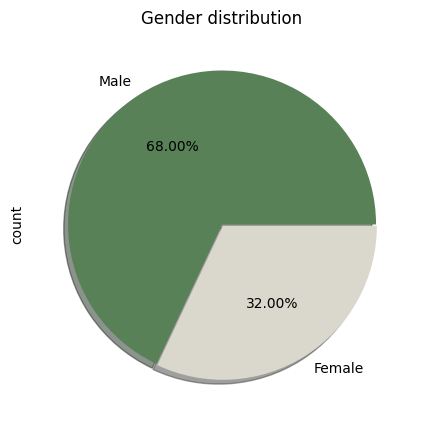

In [16]:
# Gender Distribution
plt.figure(figsize=(10,5))
df['Gender'].value_counts().plot(kind='pie',
    explode=[0,0.01],
    labels=['Male','Female'],
    colors=['#588157','#dad7cd'],
    autopct='%1.2f%%',
    shadow=True)
plt.title('Gender distribution')
plt.show()


##### We clearly understand the overall major business happens with the Male candidates

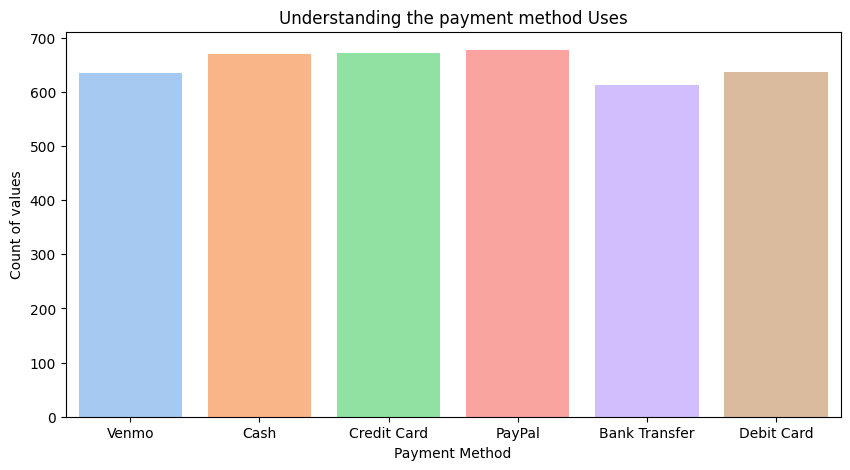

In [17]:
# Paymentmethod values
plt.figure(figsize=(10,5))
sns.countplot(df,x='Payment Method',palette='pastel',saturation=0.9)
plt.title('Understanding the payment method Uses')
plt.xlabel('Payment Method')
plt.ylabel('Count of values')
plt.show()

##### We observe that PayPal, credit cards, and cash are the three categories used most often.

<Figure size 1000x600 with 0 Axes>

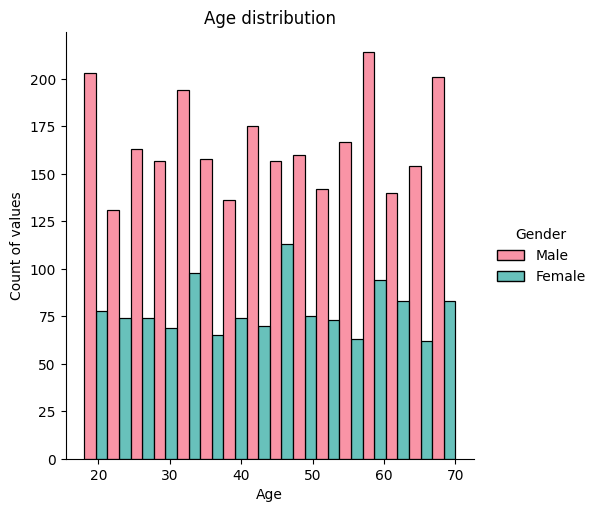

In [18]:
# Age distribution with gender
plt.figure(figsize=(10,6))
sns.displot(df,x='Age',hue='Gender',multiple="dodge",palette='husl')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count of values')
plt.show()

### In the displot, we observed that male candidates aged 56-58 engage in high shopping, and the next group aged 17-18 also displays high shopping behavior. 
### For female candidates, individuals aged 45-47 are identified as high shoppers.

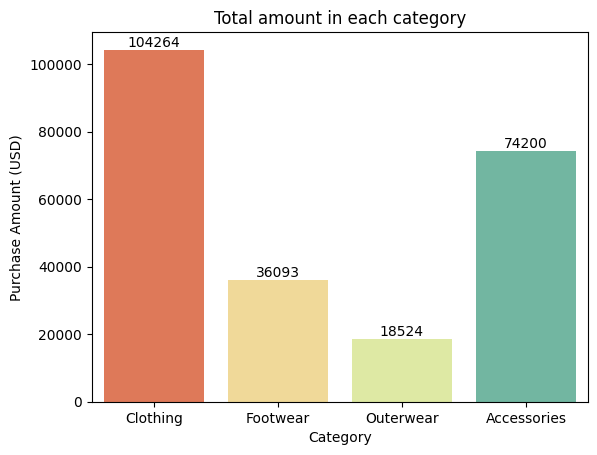

In [19]:
# Visualise the barplot to understand which category has high purchases
ax = sns.barplot(df, x="Category", y="Purchase Amount (USD)", estimator="sum", errorbar=None,palette='Spectral')
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Total amount in each category')
plt.show()

### We clearly observe that clothing brands are increasingly demanding, and we gain more profit from them. Accessories are also performing well in sales.

In [20]:
# Apply the condition to the age group
conditions=[
    (df['Age'] >=18) & (df['Age']<=26),
    (df['Age'] > 26) & (df['Age']<=35),
    (df['Age']>35) & (df['Age']<=50),
    (df['Age']>50)
]
value=['Young Adults',' Early Professional','Middle aged','Senior Aged']
df['New_age']=np.select(conditions,value)
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,New_age
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Senior Aged
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young Adults
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle aged
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adults
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle aged


In [58]:
# Size color intrest
size_intrest=df['Size'].value_counts().sort_values(ascending=False).head()
color_intrest=df['Color'].value_counts().sort_values(ascending=False).head(4)

color_size_values=pd.DataFrame({
    'Size':size_intrest.index,
    'Values':size_intrest.values,
    'Color':color_intrest.index,
    'color_Values':color_intrest.values
})
color_size_values.style.background_gradient(cmap='nipy_spectral')

,Size,Values,Color,color_Values
0,M,1755,Olive,177
1,L,1053,Yellow,174
2,S,663,Silver,173
3,XL,429,Teal,172


In [88]:
# Average Previous purchase
avg_previous_purchase=df.groupby(['Gender','Category'])['Previous Purchases'].mean().unstack().round(1)
avg_previous_purchase

Category,Accessories,Clothing,Footwear,Outerwear
Gender,,,,
Female,24.9,24.7,25.1,21.5
Male,26.1,25.4,25.3,26.5


In [59]:
# Are “subscription status” customers tied to specific payment methods?
subsription_payment_method=pd.DataFrame(df.groupby(['Subscription Status','Payment Method'])['Customer ID'].count().unstack())
subsription_payment_method.style.background_gradient(cmap='Dark2')

Payment Method,Bank Transfer,Cash,Credit Card,Debit Card,PayPal,Venmo
Subscription Status,,,,,,
No,455,497,492,446,497,460
Yes,157,173,179,190,180,174


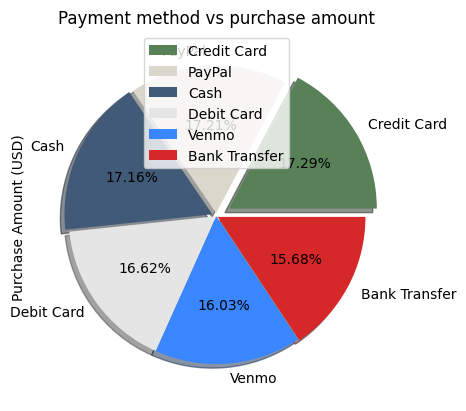

In [52]:
# Which payment methods are most popular among high-value customers?
payment_method=pd.DataFrame(df.groupby('Payment Method')['Purchase Amount (USD)'].sum().sort_values(ascending=False))
payment_method.plot(kind='pie',
    explode=[0.1,0.02,0.03,0,0,0.01],
    labels=['Credit Card', 'PayPal', 'Cash', 'Debit Card', 'Venmo','Bank Transfer'],
    colors=['#588157','#dad7cd','#415a77','#e5e5e5','#3a86ff','#d62828'],
    autopct='%1.2f%%',
    shadow=True,
    subplots=True)
plt.title('Payment method vs purchase amount')
plt.show()

## Customer segmentation 

In [22]:
# customer segmentation
Age_wise_sales=pd.DataFrame(df.groupby(['New_age','Gender'])['Purchase Amount (USD)'].sum()).unstack()
def condition_map(value):
    output='#8c1c13' if value > 50000 else ('#ffbd00' if value > 30000 & value <25000 else '#ccff33')
    return 'color: %s' % output
Age_wise_sales.style.applymap(condition_map)

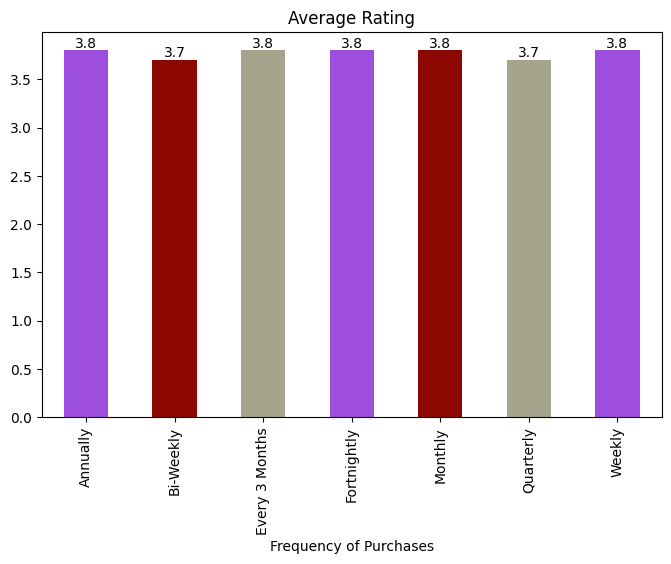

In [23]:
# Avergage Review rating
plt.figure(figsize=(8,5))
ax=(df.groupby('Frequency of Purchases')['Review Rating'].mean().round(1)).plot(kind='bar',color=['#9d4edd','#8d0801','#a5a58d'])
ax.bar_label(ax.containers[0],fontsize=10)
plt.title('Average Rating')
plt.show()

In [38]:
# Location-wise size preferred 
location_wise_size=pd.DataFrame(df.groupby(['Location','Size'])['Customer ID'].count().unstack(fill_value=0))
location_wise_size.head(10).style.background_gradient(cmap='winter_r')

Size,L,M,S,XL
Location,,,,
Alabama,23,39,17,10
Alaska,18,31,14,9
Arizona,19,23,12,11
Arkansas,18,40,13,8
California,23,47,11,14
Colorado,28,29,12,6
Connecticut,27,34,10,7
Delaware,21,42,13,10
Florida,18,43,3,4


## Does Discount impact the purchase amount

In [43]:
# Clearly, we say the  majorly not applied discount
discount_applied=pd.DataFrame(df.groupby('Discount Applied')['Purchase Amount (USD)'].count().round(1))
discount_applied

,Purchase Amount (USD)
Discount Applied,
No,2223
Yes,1677


Text(0.5, 1.0, 'Top 10 revenue locations')

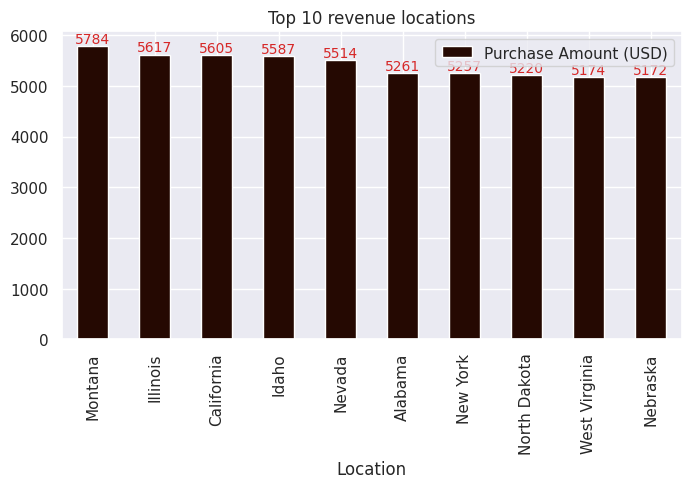

In [70]:
top_10_revenue_locations=pd.DataFrame(df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False).head(10))
sns.set_theme(style='darkgrid')
ax=top_10_revenue_locations.plot(kind='bar',figsize=(8,4),colormap ='copper',color='#250902')
ax.bar_label(ax.containers[0],fontsize=10,color='#d62828')
plt.title('Top 10 revenue locations')

In [24]:
# We create another data frame for female understad the their personal interests
female_cat=df[df['Gender']=='Female']
female_cat.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,New_age
2652,2653,23,Female,Shorts,Clothing,20,Maryland,L,Cyan,Summer,3.3,No,2-Day Shipping,No,No,46,Credit Card,Monthly,Young Adults
2653,2654,67,Female,Blouse,Clothing,36,Wisconsin,L,Lavender,Fall,4.8,No,Express,No,No,24,Venmo,Every 3 Months,Senior Aged
2654,2655,23,Female,Coat,Outerwear,70,Idaho,S,Pink,Fall,4.1,No,Next Day Air,No,No,4,PayPal,Annually,Young Adults
2655,2656,26,Female,Sunglasses,Accessories,83,Wyoming,M,Gray,Summer,3.4,No,Standard,No,No,2,Credit Card,Fortnightly,Young Adults
2656,2657,52,Female,Shorts,Clothing,76,Indiana,L,Yellow,Winter,3.6,No,Express,No,No,29,Bank Transfer,Fortnightly,Senior Aged


In [25]:
# Does subsription impact on the data
female_cat['Subscription Status'].value_counts()
# No impact on the data

Subscription Status
No    1248
Name: count, dtype: int64

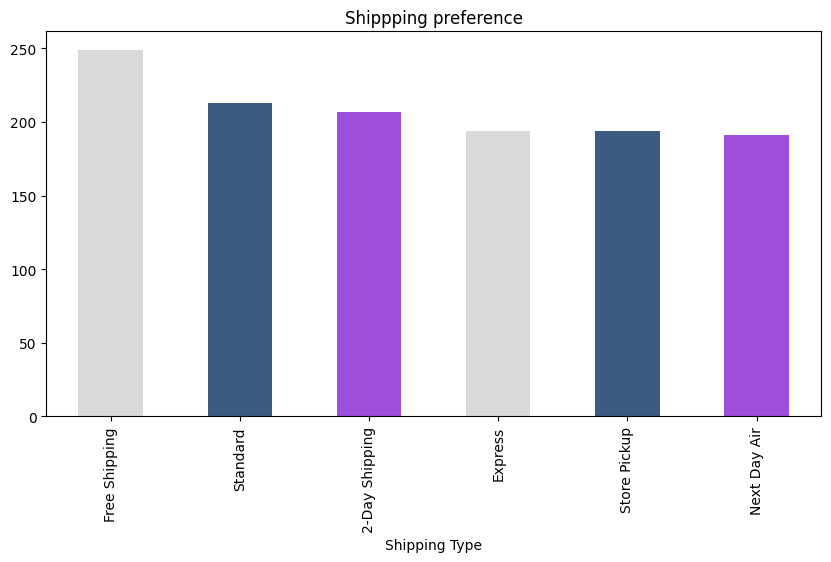

In [26]:
# Visualise the shipping preferences
plt.figure(figsize=(10,5))
female_cat['Shipping Type'].value_counts().plot(kind='bar',color=['#d9d9d9','#3d5a80','#9d4edd'])
plt.title('Shippping preference')
plt.show()

## Most of their customers prefer free shipping, which means they don't spend extra money on shipping.


In [27]:
# Average amount spent on each category
avg_amonut=pd.DataFrame(female_cat.groupby('Category')['Purchase Amount (USD)'].mean())
avg_amonut

,Purchase Amount (USD)
Category,
Accessories,60.762755
Clothing,60.496403
Footwear,59.472362
Outerwear,58.425743


## We understand that most of the female candidates spent an average amount on accessories.

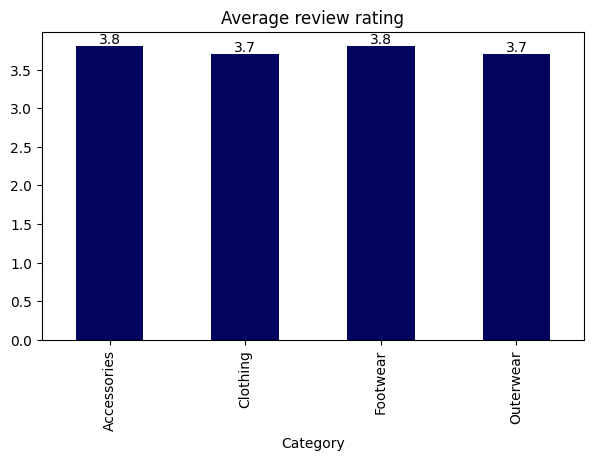

In [61]:
# Average review rating in each products
plt.figure(figsize=(7,4))
plt.title('Average review rating')
ax=(female_cat.groupby('Category')['Review Rating'].mean().round(1)).plot(kind='bar',color=['#03045e'])
ax.bar_label(ax.containers[0],fontsize=10)
plt.show()

In [29]:
def color_maping(val):
    result='#9d0208' if val>=150 else('#ffca3a' if val >=100 else '#8ac926')
    return 'color: %s' % result
season_wise_product=pd.DataFrame(female_cat[['Category','Season']].groupby(by='Category').value_counts()).unstack()
season_wise_product.style.applymap(color_maping)

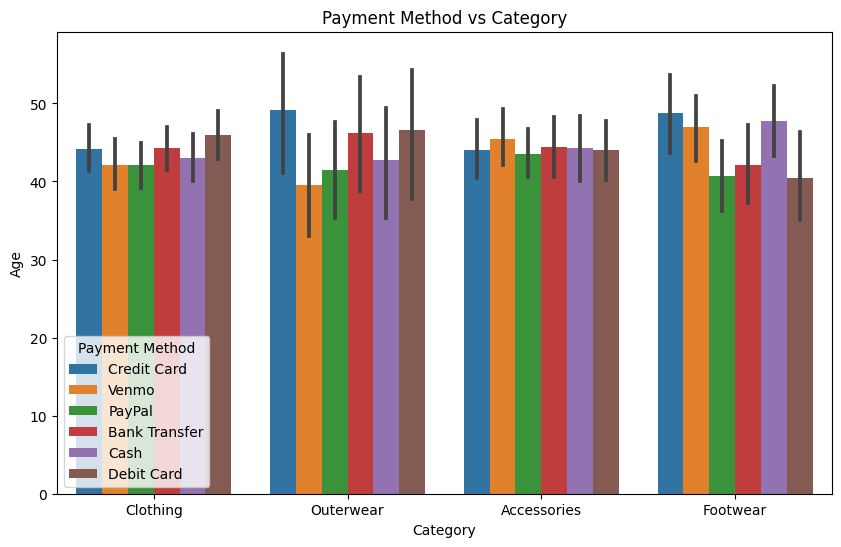

In [30]:
# Visualize Payment method vs category
plt.figure(figsize=(10,6))
sns.barplot(female_cat,x='Category',y='Age',hue='Payment Method')
plt.title('Payment Method vs Category')
plt.show()

## We clearly observed that the credit card payment method is predominantly used for both footwear and outerwear purchases.

In [31]:
# Let's analyze the female category by examining the purchased items.
each_category=pd.DataFrame(female_cat.groupby(['Category','Item Purchased'])['Purchase Amount (USD)'].sum())
def color_map(val):
    color='#c1121f' if val >=3000 else ('#ffd60a' if val >=2500 else '#386641')
    return 'color: %s' % color
each_category.style.applymap(color_map)

## Wow, we find the best insights in the female gender; they spend more money on handbags, shirts, blouses, and jewelry, but less on jeans.

# Here are my insights regarding the data and my thoughts on improving the business model.
* In the gender category, we clearly observed that males dominate shopping trends, particularly those aged 56-57. This suggests that senior individuals and teenagers are the most interested in shopping, while middle-aged individuals also contribute significantly to sales.
* It is clear that the discount has not been applied correctly.
* There is a significant difference in the subscription rates, as debit card holders largely show less interest in subscriptions.
* Major business is conducted by middle-aged people due to their higher salaries, while early career individuals tend to spend less on shopping.
* The majority of the funds have been debited via PayPal, credit card, and cash. At this point, I personally understand they are educated individuals with jobs.
* Additionally, most people prefer clothing over footwear and outerwear, although they also have a strong interest in accessories.
* We conclude that every season, females are more interested in buying clothes and accessories compared to footwear, so there is no seasonal impact on this trend.
* Female data subscriptions do not affect overall data; not all females subscribe to these products. Additionally, free shipping is preferred over other options, indicating a reluctance to pay extra for shipping.
